In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import itertools as it

import torch as pt
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.metrics import adjusted_rand_score
import math
import time

from ucf_atd_model.data import data_loc, new_data_loc
from ucf_atd_model.datasets.create_transformer_data import create_transformer_data, create_transformer_data_full

# Set a random seed for reproducibility
np.random.seed(42)
pt.manual_seed(42)

### Datapreprocessing for continuous variables using 100 bins

In [63]:
tampa_df = pd.read_csv(data_loc("tampa.csv"))
print("Done reading csv")

scaler = discretizer = None
batches = []
for batch_name, batch_df in tampa_df.groupby('batch'):
    print(f"Batch {batch_name}")
    Xb, yb, scaler, discretizer = create_transformer_data(batch_df, scaler, discretizer)
    batches.append((Xb, yb))

Done reading csv
Batch 0
Batch 1
Batch 2
Batch 3
Batch 4
Batch 5
Batch 6
Batch 7
Batch 8
Batch 9
Batch 10
Batch 11
Batch 12
Batch 13
Batch 14
Batch 15
Batch 16
Batch 17
Batch 18
Batch 19
Batch 20
Batch 21
Batch 22
Batch 23
Batch 24
Batch 25
Batch 26
Batch 27
Batch 28
Batch 29
Batch 30
Batch 31
Batch 32
Batch 33
Batch 34
Batch 35
Batch 36
Batch 37
Batch 38
Batch 39
Batch 40
Batch 41
Batch 42
Batch 43
Batch 44
Batch 45
Batch 46
Batch 47
Batch 48
Batch 49
Batch 50
Batch 51
Batch 52
Batch 53
Batch 54
Batch 55
Batch 56
Batch 57
Batch 58
Batch 59
Batch 60
Batch 61
Batch 62
Batch 63
Batch 64
Batch 65
Batch 66
Batch 67
Batch 68
Batch 69
Batch 70
Batch 71
Batch 72
Batch 73
Batch 74
Batch 75
Batch 76
Batch 77
Batch 78
Batch 79
Batch 80
Batch 81
Batch 82
Batch 83
Batch 84
Batch 85
Batch 86
Batch 87
Batch 88
Batch 89
Batch 90
Batch 91
Batch 92
Batch 93
Batch 94
Batch 95
Batch 96
Batch 97
Batch 98
Batch 99
Batch 100
Batch 101
Batch 102
Batch 103
Batch 104
Batch 105
Batch 106
Batch 107
Batch 108
Bat

KeyboardInterrupt: 

In [65]:
create_transformer_data_full(0)

FileNotFoundError: [WinError 2] Failed to open local file 'historical.parquet'. Detail: [Windows error 2] The system cannot find the file specified.


In [56]:
def evaluate_predictions_batch(truth_df, pred_df):
    truth_df = truth_df.sort_values(['track_id', 'time']).reset_index(drop=True)
    pred_df = pred_df.copy()
    
    # Merge on point_id to align
    merged = truth_df.merge(pred_df, on='point_id', how='inner')
    if len(merged) != len(truth_df):
        raise ValueError("DataFrames must have matching point_ids")
    
    # Compute true prev/next
    merged['true_prev_id'] = merged.groupby('track_id')['point_id'].shift(1)
    merged['true_next_id'] = merged.groupby('track_id')['point_id'].shift(-1)
    
    # Compute predicted prev/next (sort by predicted_track_id and time)
    merged = merged.sort_values(['predicted_track_id', 'time'])
    merged['pred_prev_id'] = merged.groupby('predicted_track_id')['point_id'].shift(1)
    merged['pred_next_id'] = merged.groupby('predicted_track_id')['point_id'].shift(-1)
    
    # Score per posit: Compare prev and next (handle None/NaN as equal if both NaN)
    def compare(a, b):
        if pd.isna(a) and pd.isna(b):
            return True
        return a == b
    
    merged['prev_correct'] = merged.apply(lambda row: compare(row['true_prev_id'], row['pred_prev_id']), axis=1)
    merged['next_correct'] = merged.apply(lambda row: compare(row['true_next_id'], row['pred_next_id']), axis=1)
    
    merged['posit_score'] = (merged['prev_correct'].astype(int) + merged['next_correct'].astype(int)) / 2.0
    
    score = merged['posit_score'].mean()
    return score

### Define the Transformer Model Components

In [57]:
class PositionalEncoding(nn.Module):
    """Adds positional information to the input embeddings."""
    def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        position = pt.arange(max_len).unsqueeze(1)
        div_term = pt.exp(pt.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = pt.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = pt.sin(position * div_term)
        pe[:, 0, 1::2] = pt.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x: pt.Tensor) -> pt.Tensor:
        """
        Args:
            x: Tensor, shape [seq_len, batch_size, embedding_dim]
        """
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)

class TrajectoryTransformer(nn.Module):
    def __init__(self, input_dim, d_model, n_head, d_hid, n_layers, dropout=0.5, n_bins=100):
        super().__init__()
        self.d_model = d_model
        self.n_bins = n_bins
        self.input_dim = input_dim
        
        embed_dim = (d_model + input_dim - 1) // input_dim  
        self.embedding = nn.Embedding(n_bins, embed_dim)  # Embed each bin
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        encoder_layers = nn.TransformerEncoderLayer(d_model, n_head, d_hid, dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, n_layers)
        self.decoder = nn.Linear(d_model, input_dim * n_bins)  # Output logits for each feature's bins

    def forward(self, src, predict_steps=0):
        batch_size, seq_len, input_dim = src.shape
        src = self.embedding(src)  # [batch, seq_len, input_dim, embed_dim]
        src = src.view(batch_size, seq_len, -1)  # [batch, seq_len, input_dim * embed_dim]

        if src.shape[-1] != self.d_model:
            pad_dim = self.d_model - src.shape[-1]
            src = pt.nn.functional.pad(src, (0, pad_dim)) 
        src = src * math.sqrt(self.d_model)
        src = self.pos_encoder(src.transpose(0, 1)).transpose(0, 1)
        embedding = self.transformer_encoder(src)  # [batch, seq_len, d_model]
        output = self.decoder(embedding)  # [batch, seq_len, input_dim * n_bins]
        
        if predict_steps > 0:
            predicted = []
            last_step = embedding[:, -1:, :]
            for _ in range(predict_steps):
                pred_input = self.pos_encoder(last_step.transpose(0, 1)).transpose(0, 1)
                pred_emb = self.transformer_encoder(pred_input)
                pred_out = self.decoder(pred_emb)
                predicted.append(pred_out)
                last_step = pred_emb
            output = pt.cat(predicted, dim=1)  # [batch, predict_steps, input_dim * n_bins]
        
        return output, embedding

In [10]:
MAX_BATCHES = 5
TRAIN_BATCHES = 4
TEST_BATCH = 7
device = pt.device("cpu")
print("Using device:", device)

results_per_batch = {}
label_arrays_per_batch = {}

Using device: cpu


In [8]:
PARAMS = {
    'SEQ_LENGTH': 10,
    'HIDDEN_DIM': 128,
    'NUM_HEADS': 2,
    'FF_DIM': 32,
    'NUM_LAYERS': 2,
    'DROPOUT': 0.1,
    'EPOCHS': 50,
    'BATCH_SIZE': 32,
    'LR': 1e-4,
    'N_BINS': 100,
    'PREDICT_STEPS': 5 
}
# Initialize model
model = TrajectoryTransformer(
    input_dim=5,  # Number of features (lat_bin, lon_bin, speed_bin, course_x_bin, course_y_bin)
    d_model=PARAMS['HIDDEN_DIM'],
    n_head=PARAMS['NUM_HEADS'],
    d_hid=PARAMS['FF_DIM'],
    n_layers=PARAMS['NUM_LAYERS'],
    dropout=PARAMS['DROPOUT'],
    n_bins=PARAMS['N_BINS']
).to(device)

optimizer = optim.Adam(model.parameters(), lr=PARAMS['LR'])
criterion = nn.CrossEntropyLoss()

In [ ]:
train_start_time = time.time()
for batch_idx, (batch_name, ais_data) in enumerate(group_tampa_df.items()):
    if batch_idx >= TRAIN_BATCHES:
        break
    
    features_for_tft = ['lat_bin', 'lon_bin', 'speed_bin', 'course_x_bin', 'course_y_bin']
    all_sequences = []
    target_sequences = []
    for track_id, group in ais_data.groupby('track_id'):
        data = group[features_for_tft].values
        target_data = group[features_for_tft].values
        if len(data) >= PARAMS['SEQ_LENGTH']:
            for i in range(len(data) - PARAMS['SEQ_LENGTH'] + 1):
                all_sequences.append(data[i:i + PARAMS['SEQ_LENGTH']])
                if i + PARAMS['SEQ_LENGTH'] + PARAMS['PREDICT_STEPS'] <= len(data):
                    target_sequences.append(target_data[i + PARAMS['SEQ_LENGTH']:i + PARAMS['SEQ_LENGTH'] + PARAMS['PREDICT_STEPS']])
                else:
                    pad_length = i + PARAMS['SEQ_LENGTH'] + PARAMS['PREDICT_STEPS'] - len(data)
                    target = target_data[i + PARAMS['SEQ_LENGTH']:] if i + PARAMS['SEQ_LENGTH'] < len(data) else target_data[-PARAMS['PREDICT_STEPS']:]
                    if pad_length > 0:
                        padding = np.repeat(target_data[-1:], pad_length, axis=0)
                        target = np.concatenate([target, padding], axis=0)[:PARAMS['PREDICT_STEPS']]
                    target_sequences.append(target)
        else:
            padded = np.zeros((PARAMS['SEQ_LENGTH'], len(features_for_tft)))
            padded[:len(data)] = data
            padded[len(data):] = data[-1] if len(data) > 0 else 0
            all_sequences.append(padded)
            target = np.zeros((PARAMS['PREDICT_STEPS'], len(features_for_tft)))
            target[:min(len(data), PARAMS['PREDICT_STEPS'])] = target_data[-min(len(data), PARAMS['PREDICT_STEPS']):]
            if len(data) < PARAMS['PREDICT_STEPS']:
                target[len(data):] = target_data[-1] if len(data) > 0 else 0
            target_sequences.append(target)

    all_sequences = np.clip(all_sequences, 0, PARAMS['N_BINS'] - 1)
    target_sequences = np.clip(target_sequences, 0, PARAMS['N_BINS'] - 1)
    sequences_tensor = pt.tensor(all_sequences).to(device)
    target_tensor = pt.tensor(target_sequences).to(device)
    

dataset = TensorDataset(sequences_tensor, target_tensor)
loader = DataLoader(dataset, batch_size=PARAMS['BATCH_SIZE'], shuffle=True)

   


=== Training on batch 0 (1/4) ===
Generated 1746 sequences (avg 7.6 per track)
  Epoch 1/50: Avg Loss = 4.1855
  Epoch 2/50: Avg Loss = 3.6172
  Epoch 3/50: Avg Loss = 3.4261
  Epoch 4/50: Avg Loss = 3.3162
  Epoch 5/50: Avg Loss = 3.2095
  Epoch 6/50: Avg Loss = 3.0970
  Epoch 7/50: Avg Loss = 2.9903
  Epoch 8/50: Avg Loss = 2.8881
  Epoch 9/50: Avg Loss = 2.7931
  Epoch 10/50: Avg Loss = 2.7018
  Epoch 11/50: Avg Loss = 2.6273
  Epoch 12/50: Avg Loss = 2.5552
  Epoch 13/50: Avg Loss = 2.4916
  Epoch 14/50: Avg Loss = 2.4385
  Epoch 15/50: Avg Loss = 2.3829
  Epoch 16/50: Avg Loss = 2.3328
  Epoch 17/50: Avg Loss = 2.2904
  Epoch 18/50: Avg Loss = 2.2524
  Epoch 19/50: Avg Loss = 2.2179
  Epoch 20/50: Avg Loss = 2.1904
  Epoch 21/50: Avg Loss = 2.1594
  Epoch 22/50: Avg Loss = 2.1301
  Epoch 23/50: Avg Loss = 2.1039
  Epoch 24/50: Avg Loss = 2.0750
  Epoch 25/50: Avg Loss = 2.0545
  Epoch 26/50: Avg Loss = 2.0362
  Epoch 27/50: Avg Loss = 2.0203
  Epoch 28/50: Avg Loss = 1.9970
  Epo

In [ ]:
for epoch in range(PARAMS['EPOCHS']):
    model.train()
    total_loss = 0
    for batch in loader:
        seq_batch, target_batch = batch
        optimizer.zero_grad()
        # print(seq_batch)
        # print("Other")
        output, _ = model(seq_batch, predict_steps=PARAMS['PREDICT_STEPS'])
        # print(output)
        output = output.view(-1, PARAMS['N_BINS'])
        target = target_batch.view(-1)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"  Epoch {epoch+1}/{PARAMS['EPOCHS']}: Avg Loss = {total_loss / len(loader):.4f}")

print(f"Training time: {time.time() - train_start_time:.2f} sec")

In [11]:
print(f"\n=== Testing on batch {TEST_BATCH} ===")
test_start_time = time.time()
ais_data = group_tampa_df[TEST_BATCH]
ground_truth_labels = ais_data['track_id']
true_k = ais_data['track_id'].nunique()

features_for_tft = ['lat_bin', 'lon_bin', 'speed_bin', 'course_x_bin', 'course_y_bin']
all_sequences = []
sequence_map = []
for track_id, group in ais_data.groupby('track_id'):
    data = group[features_for_tft].values
    if len(data) >= PARAMS['SEQ_LENGTH']:
        for i in range(len(data) - PARAMS['SEQ_LENGTH'] + 1):
            all_sequences.append(data[i:i + PARAMS['SEQ_LENGTH']])
            sequence_map.append(group.index[i:i + PARAMS['SEQ_LENGTH']])
    else:
        padded = np.zeros((PARAMS['SEQ_LENGTH'], len(features_for_tft)))
        padded[:len(data)] = data
        padded[len(data):] = data[-1] if len(data) > 0 else 0
        all_sequences.append(padded)
        indices = group.index[:len(data)].tolist()
        indices += [group.index[-1]] * (PARAMS['SEQ_LENGTH'] - len(data)) if len(data) > 0 else [0] * PARAMS['SEQ_LENGTH']
        sequence_map.append(indices[:PARAMS['SEQ_LENGTH']])

all_sequences = np.clip(all_sequences, 0, PARAMS['N_BINS'] - 1)
sequences_tensor = pt.LongTensor(all_sequences).to(device)
print(f"Generated {len(all_sequences)} sequences (avg {len(all_sequences)/true_k:.1f} per track)")


=== Testing on batch 7 ===
Generated 1237 sequences (avg 6.0 per track)


In [12]:
model.eval()
point_embeddings = np.zeros((len(ais_data), PARAMS['HIDDEN_DIM']))
point_counts = np.zeros(len(ais_data))
with pt.no_grad():
    for i, seq in enumerate(sequences_tensor):
        seq_batch = seq.unsqueeze(0)
        _, embedding = model(seq_batch, predict_steps=0)
        embedding = embedding.cpu().numpy()
        original_indices = sequence_map[i]
        for j, original_idx in enumerate(original_indices):
            point_embeddings[original_idx] += embedding[0, j, :]
            point_counts[original_idx] += 1
point_counts[point_counts == 0] = 1
tft_embeddings = point_embeddings / point_counts[:, np.newaxis]

# Clustering
kmeans_tft = KMeans(n_clusters=true_k, random_state=42, n_init='auto').fit(tft_embeddings)
ari = adjusted_rand_score(ground_truth_labels, kmeans_tft.labels_)

### Evaluate posit accuracy using atd2025 api

In [13]:
tampa_df_batch = tampa_df[tampa_df['batch'] == TEST_BATCH][['point_id', 'lat', 'lon', 'speed', 'course']]
truth_df = ais_data[['point_id', 'time', 'track_id']].merge(tampa_df_batch, on='point_id').copy()
pred_df = pd.DataFrame({
    'point_id': ais_data['point_id'],
    'track_id': kmeans_tft.labels_
})

# Ensure no NaN/None
# truth_df = truth_df.fillna(0).astype({'track_id': str})
# pred_df = pred_df.fillna(0).astype({'track_id': str})

# Save
# pred_df.to_csv(f'pred_batch1.csv', index=False)
# truth_df.to_csv(f'truth_batch1.csv', index=False)
# score, arr = atd2025.accuracy.evaluate_predictions('pred_batch1.csv','truth_batch1.csv',return_array=True)
# print(f"Score for batch {TEST_BATCH}: {score:.7f}")

### Evaluate posit accuracy using function evaluate_predictions

In [17]:
truth_df = ais_data[['point_id', 'time', 'track_id']].copy()
pred_df = pd.DataFrame({
    'point_id': ais_data['point_id'],
    'predicted_track_id': kmeans_tft.labels_
})
posit_score = evaluate_predictions(truth_df, pred_df)

results_df = pd.DataFrame({
    TEST_BATCH: {
        'Transformer': {
            'ARI': ari,
            'Posit_Accuracy': posit_score,
            'k_found': true_k,
            'k_true': true_k
        }
    }
}).T

print(f"Score for batch {TEST_BATCH}: ARI={ari:.4f}, Posit_Accuracy={posit_score:.7f}")

Score for batch 7: ARI=0.5777, Posit_Accuracy=0.5993031


In [53]:
pred_df.head()

,point_id,predicted_track_id
0,20511,118
1,24832,118
2,26047,118
3,26874,118
4,28113,118


In [54]:
truth_df.head()

,point_id,time,track_id
0,20511,04:09:59,212960000
1,24832,05:17:00,212960000
2,26047,05:26:00,212960000
3,26874,05:49:02,212960000
4,28113,05:57:59,212960000


### Bin num

In [ ]:
ais_data = group_tampa_df[0]
features_to_bin = ['lat', 'lon', 'speed', 'course_x', 'course_y']

# Discretize with N_BINS=100
n_bins = 100
discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='uniform')
bin_cols = [f'{feat}_bin' for feat in features_to_bin]
ais_data[bin_cols] = discretizer.fit_transform(ais_data[features_to_bin]).astype(int)

# Number of points per bin for each feature
bin_counts = {}
for col in bin_cols:
    counts = ais_data[col].value_counts().sort_index()
    bin_counts[col] = counts.to_dict()  # Dict for easy viewing

for feat, counts in bin_counts.items():
    print(f"\n{feat} (Number of points per bin):")
    for bin_num, count in counts.items():
        print(f"Bin {bin_num}: {count} points")


lat_bin (Number of points per bin):
Bin 0: 23 points
Bin 1: 49 points
Bin 2: 73 points
Bin 3: 48 points
Bin 4: 12 points
Bin 5: 1 points
Bin 6: 157 points
Bin 9: 1 points
Bin 10: 1 points
Bin 12: 14 points
Bin 15: 1 points
Bin 16: 49 points
Bin 17: 2 points
Bin 20: 123 points
Bin 21: 74 points
Bin 22: 17 points
Bin 23: 61 points
Bin 24: 52 points
Bin 25: 1 points
Bin 26: 1 points
Bin 27: 1 points
Bin 29: 73 points
Bin 30: 71 points
Bin 31: 25 points
Bin 32: 21 points
Bin 33: 9 points
Bin 34: 126 points
Bin 35: 9 points
Bin 36: 3 points
Bin 37: 3 points
Bin 38: 4 points
Bin 39: 13 points
Bin 40: 51 points
Bin 41: 19 points
Bin 42: 1 points
Bin 43: 42 points
Bin 44: 186 points
Bin 45: 8 points
Bin 46: 34 points
Bin 47: 54 points
Bin 48: 300 points
Bin 49: 236 points
Bin 50: 151 points
Bin 51: 7 points
Bin 52: 6 points
Bin 53: 47 points
Bin 54: 7 points
Bin 55: 24 points
Bin 56: 1 points
Bin 57: 1 points
Bin 58: 34 points
Bin 59: 32 points
Bin 60: 3 points
Bin 61: 51 points
Bin 62: 19 po

Find predictions would look like if model was 100% accurate at predicting future bin indices for AIS ship data (latitude, longitude, speed, course_x, course_y).

In [82]:
def simulate_perfect_predictions(ais_data, seq_length=10, predict_steps=5, n_bins=100):
    features_to_bin = ['lat', 'lon', 'speed', 'course_x', 'course_y']
    discretizer = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='uniform')
    bin_cols = [f'{feat}_bin' for feat in features_to_bin]
    ais_data[bin_cols] = discretizer.fit_transform(ais_data[features_to_bin]).astype(int)
    
    # Build simulated predictions
    simulated_preds = []
    for track_id, group in ais_data.groupby('track_id'):
        data = group[bin_cols].values
        if len(data) >= seq_length:
            for i in range(len(data) - seq_length + 1):
                # Input sequence bins
                input_seq = data[i:i + seq_length]
                # "Perfect" prediction: true future bins
                if i + seq_length + predict_steps <= len(data):
                    pred_seq = data[i + seq_length:i + seq_length + predict_steps]
                else:
                    pad_length = i + seq_length + predict_steps - len(data)
                    pred_seq = data[i + seq_length:]
                    padding = np.repeat(data[-1:], pad_length, axis=0)
                    pred_seq = np.concatenate([pred_seq, padding], axis=0)[:predict_steps]
                simulated_preds.append({
                    'track_id': track_id,
                    'start_index': i,
                    'input_bins': input_seq,
                    'predicted_bins': pred_seq
                })
        else:
            # Pad short tracks for input
            padded = np.zeros((seq_length, len(bin_cols)))
            padded[:len(data)] = data
            padded[len(data):] = data[-1] if len(data) > 0 else 0
            # "Perfect" prediction: padded future
            pred_seq = np.repeat(data[-1:], predict_steps, axis=0) if len(data) > 0 else np.zeros((predict_steps, len(bin_cols)))
            simulated_preds.append({
                'track_id': track_id,
                'start_index': 0,
                'input_bins': padded,
                'predicted_bins': pred_seq
            })
    
    return pd.DataFrame(simulated_preds)

sim_preds = simulate_perfect_predictions(group_tampa_df[0], seq_length=10, predict_steps=5, n_bins=100)
sim_preds.head()

,track_id,start_index,input_bins,predicted_bins
0,209641000,0,"[[32, 0, 25, 70, 95], [34, 7, 3, 7, 24], [34, ...","[[34, 7, 1, 4, 71], [34, 7, 1, 98, 38], [34, 7..."
1,209641000,1,"[[34, 7, 3, 7, 24], [34, 7, 0, 31, 96], [34, 7...","[[34, 7, 1, 98, 38], [34, 7, 3, 97, 34], [34, ..."
2,209641000,2,"[[34, 7, 0, 31, 96], [34, 7, 2, 92, 24], [34, ...","[[34, 7, 3, 97, 34], [34, 7, 4, 13, 83], [34, ..."
3,209641000,3,"[[34, 7, 2, 92, 24], [34, 7, 0, 98, 37], [34, ...","[[34, 7, 4, 13, 83], [34, 7, 1, 12, 16], [33, ..."
4,209641000,4,"[[34, 7, 0, 98, 37], [34, 7, 1, 1, 36], [34, 7...","[[34, 7, 1, 12, 16], [33, 7, 7, 1, 37], [33, 7..."


Each row represents a sequence and its perfect future bins, showing what the model should predict if 100% accurate.

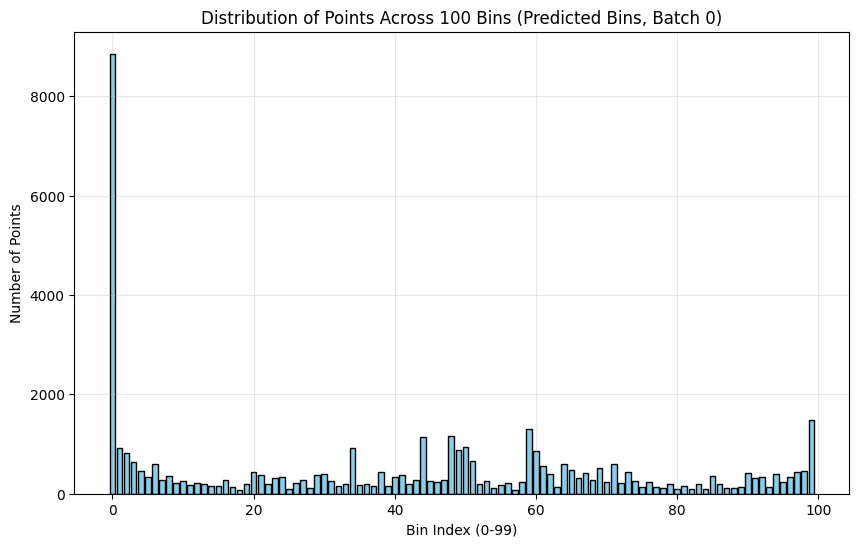

In [83]:
bin_counts = np.sum(sim_preds['predicted_bins'].apply(lambda x: np.histogram(x, bins=100, range=(0, 100))[0]), axis=0)

# Plot histogram
plt.figure(figsize=(10, 6))
plt.bar(range(100), bin_counts, color='skyblue', edgecolor='black')
plt.xlabel('Bin Index (0-99)')
plt.ylabel('Number of Points')
plt.title('Distribution of Points Across 100 Bins (Predicted Bins, Batch 0)')
plt.grid(True, alpha=0.3)
plt.show()

In [81]:
ais_data.groupby('track_id').size().describe()

count    229.000000
mean      13.240175
std       13.755029
min        1.000000
25%        2.000000
50%        8.000000
75%       19.000000
max       55.000000
dtype: float64